<a href="https://colab.research.google.com/github/Sneha-1503/AI-Based-Mental-Health-Monitoring-Solution/blob/main/AI_Based_Mental_Health_Monitoring_Solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [5]:
from google.colab import files

uploaded = files.upload()


Saving Mental Health Dataset.csv to Mental Health Dataset.csv


In [6]:
df = pd.read_csv("Mental Health Dataset.csv")

In [7]:
df.head()

,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,8/27/2014 11:29,Female,United States,Corporate,NaN,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,8/27/2014 11:31,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,8/27/2014 11:32,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
3,8/27/2014 11:37,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes
4,8/27/2014 11:43,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes


In [8]:
df.shape

(292364, 17)

In [9]:
df.columns

Index(['Timestamp', 'Gender', 'Country', 'Occupation', 'self_employed',
       'family_history', 'treatment', 'Days_Indoors', 'Growing_Stress',
       'Changes_Habits', 'Mental_Health_History', 'Mood_Swings',
       'Coping_Struggles', 'Work_Interest', 'Social_Weakness',
       'mental_health_interview', 'care_options'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292364 entries, 0 to 292363
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   Timestamp                292364 non-null  object
 1   Gender                   292364 non-null  object
 2   Country                  292364 non-null  object
 3   Occupation               292364 non-null  object
 4   self_employed            287162 non-null  object
 5   family_history           292364 non-null  object
 6   treatment                292364 non-null  object
 7   Days_Indoors             292364 non-null  object
 8   Growing_Stress           292364 non-null  object
 9   Changes_Habits           292364 non-null  object
 10  Mental_Health_History    292364 non-null  object
 11  Mood_Swings              292364 non-null  object
 12  Coping_Struggles         292364 non-null  object
 13  Work_Interest            292364 non-null  object
 14  Social_Weakness     

In [11]:
df.describe()

,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
count,292364,292364,292364,292364,287162,292364,292364,292364,292364,292364,292364,292364,292364,292364,292364,292364,292364
unique,580,2,35,5,2,2,2,5,3,3,3,3,2,3,3,3,3
top,8/27/2014 11:43,Male,United States,Housewife,No,No,Yes,1-14 days,Maybe,Yes,No,Medium,No,No,Maybe,No,No
freq,2384,239850,171308,66351,257994,176832,147606,63548,99985,109523,104018,101064,154328,105843,103393,232166,118886


In [12]:
df.sample(5)

,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
105200,8/28/2014 15:48,Male,United States,Others,No,Yes,No,1-14 days,Maybe,Maybe,Yes,Medium,Yes,Yes,Maybe,No,Yes
249088,8/28/2014 12:23,Male,United States,Corporate,No,No,No,1-14 days,No,Yes,No,Low,Yes,No,Yes,No,No
217503,8/27/2014 14:31,Male,United States,Business,Yes,No,No,1-14 days,Maybe,Yes,No,Medium,No,No,Yes,No,Yes
209941,2/24/2015 9:13,Male,United Kingdom,Corporate,No,No,Yes,More than 2 months,No,No,Maybe,High,Yes,Maybe,Yes,No,Yes
284337,2/21/2015 4:16,Male,Canada,Student,No,Yes,No,1-14 days,No,No,No,Low,Yes,Yes,Maybe,No,Not sure


In [13]:
df.isnull().sum()

,0
Timestamp,0
Gender,0
Country,0
Occupation,0
self_employed,5202
family_history,0
treatment,0
Days_Indoors,0
Growing_Stress,0
Changes_Habits,0


In [14]:
df.duplicated().sum()

np.int64(2313)

In [15]:
df = df.drop_duplicates()

In [31]:
df = df.drop("Timestamp", axis=1)

In [32]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

for column in df.columns:
    df[column] = encoder.fit_transform(df[column])

In [33]:
df.head()

,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,0,34,1,2,0,1,0,2,1,2,2,0,1,2,1,1
1,0,34,1,2,1,1,0,2,1,2,2,0,1,2,1,0
2,0,34,1,2,1,1,0,2,1,2,2,0,1,2,1,2
3,0,34,1,0,1,1,0,2,1,2,2,0,1,2,0,2
4,0,34,1,0,1,1,0,2,1,2,2,0,1,2,1,2


In [34]:
X = df.drop("treatment", axis=1)

y = df["treatment"]

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [36]:
print(X_train.shape)
print(X_test.shape)

(232040, 15)
(58011, 15)


In [38]:

X = pd.get_dummies(X, drop_first=True)


In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [40]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [42]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.737791108582855
              precision    recall  f1-score   support

           0       0.75      0.70      0.73     28774
           1       0.73      0.77      0.75     29237

    accuracy                           0.74     58011
   macro avg       0.74      0.74      0.74     58011
weighted avg       0.74      0.74      0.74     58011

[[20211  8563]
 [ 6648 22589]]


In [43]:
df.columns

Index(['Gender', 'Country', 'Occupation', 'self_employed', 'family_history',
       'treatment', 'Days_Indoors', 'Growing_Stress', 'Changes_Habits',
       'Mental_Health_History', 'Mood_Swings', 'Coping_Struggles',
       'Work_Interest', 'Social_Weakness', 'mental_health_interview',
       'care_options'],
      dtype='object')

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)

    print(f"{name}: {acc:.4f}")

Logistic Regression: 0.7009
Decision Tree: 0.7346
Random Forest: 0.7378


In [45]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)

print(importance.head(10))

                    Feature  Importance
1                   Country    0.275970
4            family_history    0.233816
14             care_options    0.202855
13  mental_health_interview    0.064830
3             self_employed    0.061580
0                    Gender    0.042212
5              Days_Indoors    0.019937
2                Occupation    0.019505
12          Social_Weakness    0.012690
9               Mood_Swings    0.012596


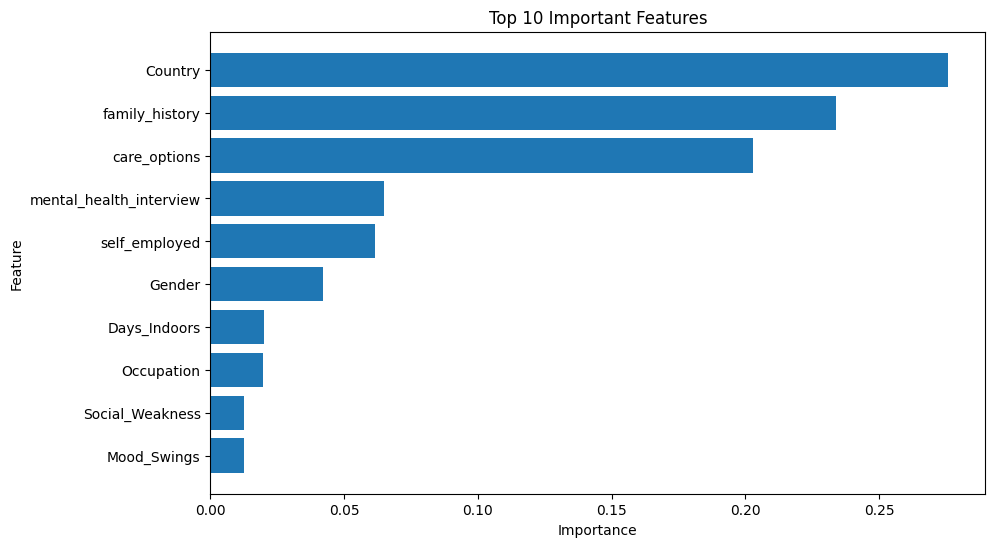

In [46]:
plt.figure(figsize=(10,6))

plt.barh(
    importance['Feature'][:10],
    importance['Importance'][:10]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Important Features")

plt.gca().invert_yaxis()

plt.show()

In [47]:
import joblib

joblib.dump(model, "mental_health_model.pkl")

print("Model saved successfully!")

Model saved successfully!
